# **Mathematics of Financial Markets**

<img style="float: right;" src="https://github.com/torreblanca99/course_financial_applications/blob/develop/docs/img/logo_bourbaki.png?raw=1" width="100"/>

## **Module I:** 
#### Topic: Bonds and Forward Contracts

##### Name: Julio César Avila Torreblanca

- **Contents**:
    - Notes:
        - Bonds
        - Forwars
    - Code:
        - Bonds
        - Forwars
       
----

# 📒 Notes

## 1. Simple Interest
Simple interest is the interest calculated only on the principal amount of a loan or investment. It does not compound; the interest is always calculated on the original principal amount, and it does not earn interest on previously accumulated interest.

The simple interest ($I$) is calculated as:

$$I = P \cdot r \cdot t$$

Where:
- $P$: Principal amount or initial capital.
- $r$: Annual interest rate expressed as a decimal (e.g., 5% = 0.05).
- $t$: Time in years (or the fraction of a year corresponding to the period).

The total amount ($A$) to be paid or received at the end of the period is:
$$A = P + I = P (1 + r \cdot t)$$

## 2. Definition of Zero-Coupon Bond
A zero-coupon bond (also known as a zero-bond or discount bond) is a debt instrument that does not pay periodic interest (coupons) to its holders. Instead, it is sold at a discount to its face value (or par value), and the investor receives the full face value on the maturity date. The investor's return comes from the difference between the discounted purchase price and the face value received at maturity.

The current price ($P_0$) of a zero-coupon bond is calculated by discounting its face value back to the present:

$$P_0 = \frac{FV}{(1 + y)^T}$$

Where:
- $FV$: Face value (or par value) of the bond, which is the amount paid at maturity.
- $y$: Yield to maturity (YTM) or the discount rate for the bond, expressed annually and as a decimal.
- $T$: Time to maturity of the bond in years.


## 3. Compound Interest
Compound interest is the interest calculated not only on the initial principal but also on the accumulated interest from previous periods. This means that interest earned (or paid) in one period is added to the principal for the calculation of interest in the next period, leading to exponential growth of money over time.

The total amount ($A$) accumulated at the end of a period with compound interest is calculated as:

$$A = P \left(1 + \frac{r}{n}\right)^{nt}$$

Where:
- $P$: Principal amount or initial capital.
- $r$: Nominal annual interest rate expressed as a decimal.
- $n$: Number of times the interest is compounded per year (e.g., for annual compounding $n=1$, semi-annual $n=2$, quarterly $n=4$, monthly $n=12$).
- $t$: Time in years.

If interest is compounded continuously, the formula is:

$$A = P \cdot e^{rt}$$


## 4. Coupon Bond
A coupon bond is a debt instrument that pays periodic interest payments (called coupons) to its holders at regular intervals (e.g., annually or semi-annually) until the maturity date. At maturity, the bondholder receives the face value (or principal) of the bond, in addition to the final coupon payment.
Coupon bonds can be of different types:
    a. Fixed-Rate Coupon Bond (Annuity): the coupon payment is a fixed amount throughout the life of the bond, determined by the fixed coupon rate and the bond's face value. These regular payments are analogous to an annuity.
    The price ($P_B$) of a fixed-rate coupon bond is the sum of the present value of all coupon payments plus the present value of the face value (principal) to be received at maturity.

$$P_B = \sum_{i=1}^{N} \frac{C}{(1 + y)^i} + \frac{FV}{(1 + y)^N}$$

Where:
- $C$: Coupon payment per period (e.g., $C = \text{Coupon Rate} \times FV$).
- $FV$: Face value of the bond.
- $y$: Yield to maturity (YTM) or the discount rate per period.
- $N$: Total number of coupon payments until maturity.

If coupon payments are frequent (e.g., semi-annual), the rate $y$ and the number of periods $N$ must be adjusted for the frequency (e.g., if $y$ is annual, use $y/2$ and $N \times 2$ for semi-annual payments).

## 5. Forward Rate and FRA (Forward Rate Agreement) Contract

A forward rate is an interest rate agreed upon today for a future transaction that will begin at a future date and end at another future date. In essence, it is the market's expectation of a future interest rate.

A ***Forward Rate Agreement (FRA)*** is an over-the-counter (OTC) contract between two parties to fix an interest rate for a specified future period, on a determined notional amount. It does not involve the exchange of principal, but rather the payment of the difference between the agreed forward rate and a reference rate (e.g., LIBOR or SOFR) at the future settlement date. It is used to hedge against the risk of interest rate fluctuations.

To calculate an implied forward rate ($F_{T_1, T_2}$) between two future times $T_1$ and $T_2$, derived from current spot rates $R_1$ and $R_2$ for periods $T_1$ and $T_2$ (both from the current time $t=0$), the following relationship is used (assuming continuous compounding):

$$e^{R_2 T_2} = e^{R_1 T_1} \cdot e^{F_{T_1, T_2} (T_2 - T_1)}$$

Solving for $F_{T_1, T_2}$:

$$F_{T_1, T_2} = \frac{R_2 T_2 - R_1 T_1}{T_2 - T_1}$$

Where:
- $R_1$: Spot rate for the period $T_1$ (from today until $T_1$).
- $R_2$: Spot rate for the period $T_2$ (from today until $T_2$).
- $T_1$: Time from today to the start of the forward period.
- $T_2$: Time from today to the end of the forward period.
- $F_{T_1, T_2}$: Forward rate for the period spanning from $T_1$ to $T_2$.

For an FRA, the payment ($P_{FRA}$) at maturity is calculated as the difference between the market reference rate ($R_{market}$) and the agreed forward rate ($F$), multiplied by the notional amount ($N$) and the term of the contract (e.g., $T_2-T_1$), and then discounted to the payment date. If the market rate is higher than the FRA rate, the buyer of the FRA receives a payment. If it is lower, the buyer pays.


$$P_{FRA} = N \cdot (R_{market} - F) \cdot \frac{\text{Days}}{360} \cdot \frac{1}{(1 + R_{market} \cdot \frac{\text{Days}}{360})}$$

Where:
- $N$: Notional amount of the contract.
- $R_{market}$: Market reference rate observed at the start of the forward period (e.g., LIBOR).
- $F$: Forward rate agreed upon in the FRA contract.
- $\text{Days}$: Number of days in the forward period.
- $360$: Day count convention base (can be 365 in some markets).

--------


# Coding

# 1. Libraries and Parameters

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import yfinance as yf

# 2. Zero-coupon Bond

$$VP = \frac{VF}{(1+r)^{T}}$$

In [2]:
class ZeroCouponBond:
    def __init__(self, face_value, risk_free_rate, time_to_maturity):
        """
        Initializer or constructor.
        """
        self.face_value = face_value
        self.risk_free_rate = risk_free_rate
        self.time_to_maturity = time_to_maturity

    def price(self):
        """
        Compute the price of the zero-coupon bond.

        Returns:
        float: Price.
        """
        return self.face_value / (1 + self.risk_free_rate) ** self.time_to_maturity



In [3]:
# Example usage
face_value = 1000
risk_free_rate = 0.03
time_to_maturity = 5

bond = ZeroCouponBond(
    face_value, 
    risk_free_rate, 
    time_to_maturity
)
bond_price = bond.price()
print(f"The price of the zero-coupon bond is: {bond_price:.2f}")

The price of the zero-coupon bond is: 862.61


# 3. Coupon Bond

$$ P = \sum_{t=1}^{N} \frac{C}{(1+r)^{t}} + \frac{F}{(1+r)^{N}}  $$

In [ ]:
class CouponBond:
    def __init__(self, f_v, c_r, y_to_mat, ytm):

        self.face_value = f_v
        self.coupon_rate = c_r
        self.years_to_maturity = y_to_mat
        self.ytm = ytm
        self.precio = self.price()

    def price(self):
        """
        Compute the price of the coupon bond.
        Returns:
            float: Price.
        """

        annual_coupon_payment = self.face_value * (self.coupon_rate / 100)
        bond_price = 0
        # Present value of the coupons
        for t in range(1, self.years_to_maturity + 1):
            bond_price += annual_coupon_payment / ((1 + self.ytm / 100) ** t)
        bond_price += self.face_value / ((1 + self.ytm / 100) ** self.years_to_maturity)
        
        return bond_price

In [8]:
# Values
face_value = 500
coupon_rate = 5
years_to_maturity = 4
ytm = 11

coupon = CouponBond(face_value, coupon_rate, years_to_maturity, ytm)

print(f"The price of the coupon bond is: {coupon.price():.2f}")

The price of the coupon bond is: 406.93


## 3.1 Vasicek Model

$$ P = \sum_{t=1}^{N} \frac{C}{(1+r)^{t}} + \frac{F}{(1+r)^{N}}  $$

# 3. Coupon Bond

$$ P = \sum_{t=1}^{N} \frac{C}{(1+r)^{t}} + \frac{F}{(1+r)^{N}}  $$

## 3.1 Vasicek Model
It is assumed that the risk-free rate is a stochastic process that satisfies the following SDE (Stochastic Differential Equation):

$$dr_t= a(b-r_t)\, dt + \sigma \, dW_t$$

The solution is:

$$ r_t = r_0 e^{-a t} +  b\left(1- e^{-a t}\right) + \sigma e^{-a t}\int_0^t e^{a s}\,dW_s$$


In [ ]:
# Zero Coupon
def vasicek_bond_price(r, a, b, sigma, t, T):
    def B(t, T, a):
        return (1 - np.exp(-a * (T - t))) / a

    def A(t, T, a, b, sigma):
        B_t_T = B(t, T, a)
        return np.exp((b - (sigma**2 / (2 * a**2))) * (B_t_T - (T - t)) - (sigma**2 / (4 * a)) * B_t_T**2)

    B_t_T = B(t, T, a)
    A_t_T = A(t, T, a, b, sigma)

    return A_t_T * np.exp(-B_t_T * r)

def vasicek_paths(r0, a, b, sigma, T, dt, n_paths):
    """
    Simulates paths of the Vasicek process that models the interest rate

    Parameters:
    r0 (float): Initial interest rate.
    a (float): Speed of reversion.
    b (float): Long-term average interest rate.
    sigma (float): Interest rate volatility.
    T (float): Total time for simulations.
    dt (float): Size of each time step.
    n_paths (int): Number of simulated paths.

    Returns:
    np.ndarray: Paths simulating the interest rate.
    """
    n_steps = int(T / dt)
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = r0

    for t in range(1, n_steps + 1):
        dt_sqrt = np.sqrt(dt)
        dW = np.random.normal(0, dt_sqrt, n_paths)
        r_t = paths[t - 1]
        dr = a * (b - r_t) * dt + sigma * dW
        paths[t] = r_t + dr

    return paths


In [10]:
# Coupon Zero
def vasicek_bond_price(r, a, b, sigma, t, T):
    def B(t, T, a):
        return (1 - np.exp(-a * (T - t))) / a

    def A(t, T, a, b, sigma):
        B_t_T = B(t, T, a)
        return np.exp((b - (sigma**2 / (2 * a**2))) * (B_t_T - (T - t)) - (sigma**2 / (4 * a)) * B_t_T**2)

    B_t_T = B(t, T, a)
    A_t_T = A(t, T, a, b, sigma)

    return A_t_T * np.exp(-B_t_T * r)

def vasicek_paths(r0, a, b, sigma, T, dt, n_paths):
    """
    Simula trayectorias del proceso de Vasicek que simula la tasa de interés

    Parametros:
    r0 (float): Tasa de interes inicial.
    a (float): Speed of reversion.
    b (float): Tasa promedio a largo plazo.
    sigma (float): Volatidlidad de tasa de interes.
    T (float): Tiempo total para simulaciones.
    dt (float): Tamaño de cada paso temporal.
    n_paths (int): Número de caminos simulados.

    Returns:
    np.ndarray: Caminos que simulan la tasa de interés.
    """
    n_steps = int(T / dt)
    paths = np.zeros((n_steps + 1, n_paths))
    paths[0] = r0

    for t in range(1, n_steps + 1):
        dt_sqrt = np.sqrt(dt)
        dW = np.random.normal(0, dt_sqrt, n_paths)
        r_t = paths[t - 1]
        dr = a * (b - r_t) * dt + sigma * dW
        paths[t] = r_t + dr

    return paths

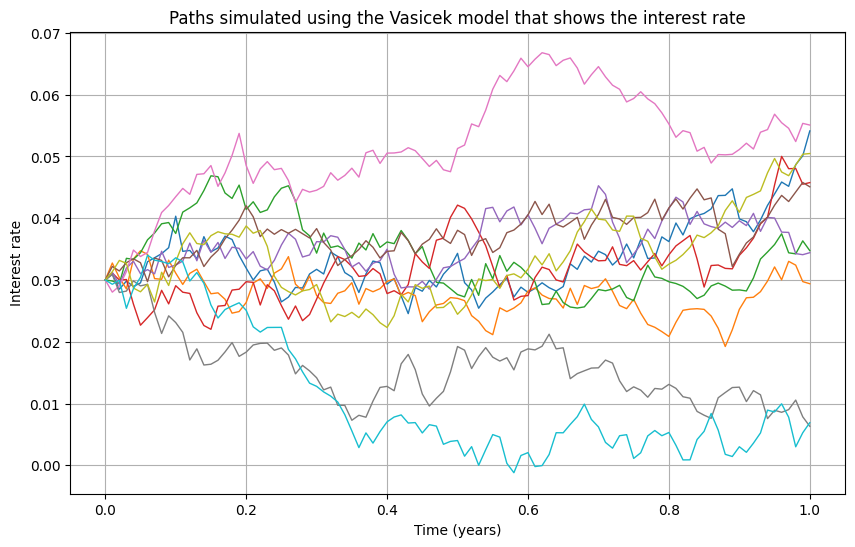

In [12]:
# Example
r0 = 0.03
a = 0.1
b = 0.05
sigma = 0.02
T = 1.0
dt = 0.01
n_paths = 10

paths = vasicek_paths(r0, a, b, sigma, T, dt, n_paths)

# Visualization
time_grid = np.linspace(0, T, int(T / dt) + 1)
plt.figure(figsize=(10, 6))
for i in range(n_paths):
    plt.plot(time_grid, paths[:, i], lw=1)
plt.title('Paths simulated using the Vasicek model that shows the interest rate')
plt.xlabel('Time (years)')
plt.ylabel('Interest rate')
plt.grid(True)
plt.show()

# 4. Forward

In [14]:

data = yf.download(  # or pdr.get_data_yahoo(...
        # tickers list or string as well
        tickers = "GOOG NVDA",

        # use "period" instead of start/end
        # valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (optional, default is '1mo')
        period = "1y",

        # fetch data by interval (including intraday if period < 60 days)
        # valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (optional, default is '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (optional, default is 'column')
        # group_by = 'ticker',
    ).loc[:, 'Close']
data

/var/folders/dv/9p478lkj2vs4k52t0dflfcb1qd6rhx/T/ipykernel_70333/2589854003.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(  # or pdr.get_data_yahoo(...
[*********************100%***********************]  2 of 2 completed


Ticker,GOOG,NVDA
Date,,
2024-08-16,163.952911,124.540657
2024-08-19,167.595413,129.958923
2024-08-20,168.152756,127.209816
2024-08-21,166.829117,128.459427
2024-08-22,164.699326,123.700920
...,...,...
2025-08-11,201.630005,182.059998
2025-08-12,204.160004,183.160004
2025-08-13,203.029999,181.589996


## 4.1 Arbitrage-free price

In [16]:
spot_price = data['NVDA'][-1]
spot_price


/var/folders/dv/9p478lkj2vs4k52t0dflfcb1qd6rhx/T/ipykernel_70333/3237941357.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  spot_price = data['NVDA'][-1]


np.float64(180.4499969482422)

In [17]:

# Precio justo, suponiendo que la tasa libre de riesgo es constante
r = 0.052
T = 90/365
forward_price = spot_price * (1 + r * T)
forward_price

np.float64(182.76371197760594)

In [18]:
# Precio justo cuando se toma como proceso continuo
r = 0.052
T = 90/365
forward_price = spot_price * np.exp(r*T)
forward_price

np.float64(182.77860870971276)

## 4.2 Forward valuation
$$ V_t = S_t - F e^{-r(T - t)} $$

In [24]:
def forward_contract_value(spot_price, forward_price, risk_free_rate, time_to_maturity, current_time):
    # Contract value
    value = spot_price - forward_price * np.exp(-risk_free_rate * (time_to_maturity - current_time))
    
    return value

In [25]:
# Parameters
spot_price = 100
forward_price = 105
risk_free_rate = 0.05
time_to_maturity = 365/365 # 1
current_time = 1/365

value = forward_contract_value(spot_price, forward_price, risk_free_rate, time_to_maturity, current_time)

print(f"The value of the forward contract is: {value}")

The value of the forward contract is: 0.1072274231896273
